# 📊 Airbnb Listings Analysis

## Introduction

Airbnb is one of the world's leading online platforms for booking unique accommodations and travel experiences. It allows hosts to rent out properties such as apartments, villas, cabins, and hotels to travelers across different countries.

This project focuses on analyzing Airbnb listing data to understand pricing patterns, customer ratings, reviews, and property characteristics across various countries. The analysis helps identify important trends and insights related to Airbnb listings.

## Objectives

- Explore and understand the Airbnb dataset  
- Perform data cleaning and preprocessing  
- Analyze listing distribution across countries  
- Study pricing patterns of Airbnb properties  
- Analyze ratings and reviews distribution  
- Identify relationships between different numerical features  
- Generate insights using data visualization  

## Import Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [56]:
data = pd.read_csv("airbnb.csv")
data

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504.0,Perla bungalov,4.71,64,Mehmetcan,357334205,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766.0,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164.0,cottages sataplia,4.85,68,Giorgi,409690853,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422.0,Sapanca Breathable Bungalow,5,13,Melih,401873242,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886.0,Bungalov Ev 2,New,0,Arp Sapanca,414884116,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12800,12800,44697740.0,"Brown Dome House No. 3, full of healing",4.94,16,Aidan,161552316,"Imhoe-myeon, Jindo, South Jeolla Province, Sou...","4 guests,8 bathrooms","Kitchen,Wifi,Free parking on premises,Private ...",...,4288,South Korea,8,0,4,0,0,0,3 00 pm - 11 00 pm,11 00 am
12801,12801,29975283.0,Bubble Hotel Ubud with Bathtub under the Sky,4.67,6,Martha,118954227,"Gianyar, Indonesia","2 guests,1 bedroom,1 bed,Toilet with sink","Wifi,Free on-street parking,Air conditioning,G...",...,15200,Indonesia,0,1,2,1,1,0,3 00 pm - 10 00 pm,12 00 pm
12802,12802,32977697.0,Paradise Eco Hub,4.67,3,Silas,175214568,"Kabale, Uganda","2 guests,1 bedroom,2 beds,1 private bathroom","Wifi,Breakfast,Long-term stays allowed,Unavail...",...,9103,Uganda,1,2,2,0,1,0,After 3 00 pm,NaN
12803,12803,8006146.0,WisDOME - Mentigi Bay Village - Gilis - Lombok,4.86,7,Cempaka,718423,"Gunung Sari, Nusa Tenggara Barat, Indonesia","8 guests,2 bedrooms,4 beds,2.5 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,42262,Indonesia,2,4,8,0,2,0,Flexible,12 00 pm


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    12805 non-null  int64  
 1   id            12805 non-null  float64
 2   name          12805 non-null  object 
 3   rating        12805 non-null  object 
 4   reviews       12805 non-null  object 
 5   host_name     12797 non-null  object 
 6   host_id       12805 non-null  int64  
 7   address       12805 non-null  object 
 8   features      12805 non-null  object 
 9   amenities     12805 non-null  object 
 10  safety_rules  12805 non-null  object 
 11  hourse_rules  12805 non-null  object 
 12  img_links     12805 non-null  object 
 13  price         12805 non-null  int64  
 14  country       12805 non-null  object 
 15  bathrooms     12805 non-null  int64  
 16  beds          12805 non-null  int64  
 17  guests        12805 non-null  int64  
 18  toiles        12805 non-nu

#  Data Cleaning and Preprocessing

In [58]:
data.head()

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504.0,Perla bungalov,4.71,64,Mehmetcan,357334205,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766.0,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164.0,cottages sataplia,4.85,68,Giorgi,409690853,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422.0,Sapanca Breathable Bungalow,5,13,Melih,401873242,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886.0,Bungalov Ev 2,New,0,Arp Sapanca,414884116,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


## Removing Unnecessary Columns

The dataset contained several columns that were not required for analysis, such as IDs, image links, and host-related identifiers.  
These columns were removed to make the dataset cleaner and more focused for analysis.

In [59]:
data.drop(columns=[
    'Unnamed: 0',
    'id',
    'host_id',
    'host_name',
    'img_links'
], inplace=True)

#### Removing Text-Based Columns

Several columns contained lengthy text information that was not required for the current exploratory data analysis.
These columns were removed to simplify the dataset and focus on numerical and categorical analysis.

In [60]:
# Removing unnecessary text-based columns

data.drop(columns=[
    'features',
    'amenities',
    'safety_rules',
    'hourse_rules',
    'checkin',
    'checkout'
], inplace=True)

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       12805 non-null  object
 1   rating     12805 non-null  object
 2   reviews    12805 non-null  object
 3   address    12805 non-null  object
 4   price      12805 non-null  int64 
 5   country    12805 non-null  object
 6   bathrooms  12805 non-null  int64 
 7   beds       12805 non-null  int64 
 8   guests     12805 non-null  int64 
 9   toiles     12805 non-null  int64 
 10  bedrooms   12805 non-null  int64 
 11  studios    12805 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 1.2+ MB


## Handling Missing Values

- The `rating` column contained non-numeric values such as `"New"`.
- These values were converted into `NaN` using `pd.to_numeric()` with `errors='coerce'`.
- Listings with no reviews had missing ratings, so the `NaN` values were kept as they represent unavailable ratings rather than incorrect data.

In [62]:
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
print("Missing ratings:", data['rating'].isnull().sum())

Missing ratings: 4238


The `reviews` column was originally stored as an object datatype.  
It was converted into numeric format to enable proper analysis and visualization.

In [63]:
data['reviews'].unique()[:10]

array(['64', '0', '68', '13', '3', '77', '55', '116', '23', '21'],
      dtype=object)

In [64]:
data['reviews'] = pd.to_numeric(data['reviews'].str.replace(',', '', regex=False), errors='coerce')
print("Missing reviews:", data['reviews'].isnull().sum())

Missing reviews: 0


## Renaming Column

The column name `toiles` (a typo in the dataset) was renamed to `toilets` for better readability and consistency.

In [65]:
data.rename(columns={'toiles': 'toilets'}, inplace=True)
print("Columns after rename:", data.columns.tolist())

Columns after rename: ['name', 'rating', 'reviews', 'address', 'price', 'country', 'bathrooms', 'beds', 'guests', 'toilets', 'bedrooms', 'studios']


## Removing Duplicate Records

Duplicate rows were identified and removed from the dataset to improve data quality.

In [66]:
print("Duplicates before:", data.duplicated().sum())
data = data.drop_duplicates()
print("Duplicates after:", data.duplicated().sum())

Duplicates before: 9
Duplicates after: 0


## Final Dataset Information

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12796 entries, 0 to 12804
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       12796 non-null  object 
 1   rating     8567 non-null   float64
 2   reviews    12796 non-null  int64  
 3   address    12796 non-null  object 
 4   price      12796 non-null  int64  
 5   country    12796 non-null  object 
 6   bathrooms  12796 non-null  int64  
 7   beds       12796 non-null  int64  
 8   guests     12796 non-null  int64  
 9   toilets    12796 non-null  int64  
 10  bedrooms   12796 non-null  int64  
 11  studios    12796 non-null  int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 1.3+ MB


In [68]:
data.describe()

,rating,reviews,price,bathrooms,beds,guests,toilets,bedrooms,studios
count,8567.000000,12796.000000,1.279600e+04,12796.000000,12796.000000,12796.000000,12796.000000,12796.000000,12796.000000
mean,4.857475,36.165442,1.770708e+04,1.874726,3.317443,5.215067,0.019225,2.136761,0.023601
std,0.140803,66.094091,4.570832e+04,2.092062,4.038971,3.809678,0.137319,2.359663,0.151809
min,3.000000,0.000000,3.930000e+02,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,4.770000,1.000000,3.994000e+03,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000
50%,4.890000,10.000000,8.177000e+03,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000
75%,4.980000,42.000000,1.607650e+04,2.000000,4.000000,6.000000,0.000000,3.000000,0.000000
max,5.000000,1003.000000,1.907963e+06,50.000000,98.000000,16.000000,1.000000,50.000000,1.000000


## Exploratory Data Analysis (EDA)
### 1. Top 10 Countries by Listings

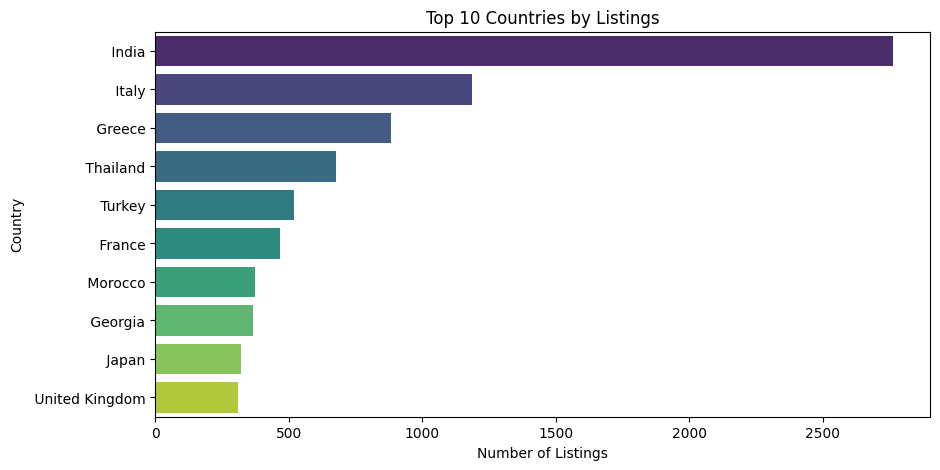

In [69]:
plt.figure(figsize=(10,5))

top_country = data['country'].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    hue=top_country.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Countries by Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Country')

plt.show()

#### Insights
- India has the highest number of Airbnb listings in the dataset.
- Italy and Greece also show a strong number of Airbnb properties.
- Listings are unevenly distributed, with a few countries contributing the majority of properties.
- Asian and European countries dominate the top listing counts.

### 2. Average Price by Country

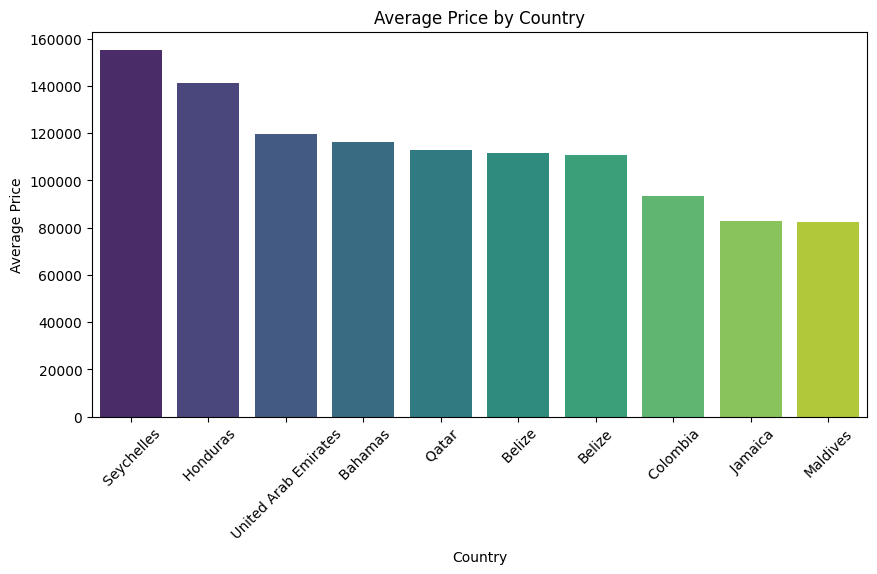

In [70]:
avg_price = data.groupby('country')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    hue=avg_price.index,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)

plt.title('Average Price by Country')
plt.xlabel('Country')
plt.ylabel('Average Price')

plt.show()

#### Insights
- Seychelles has the highest average Airbnb price among the listed countries.
- Honduras and the United Arab Emirates also have relatively expensive Airbnb properties.
- The average price varies significantly across countries, indicating differences in tourism demand and property standards.
- Maldives and Jamaica show comparatively lower average prices among the top countries.

### 3. Rating Distribution


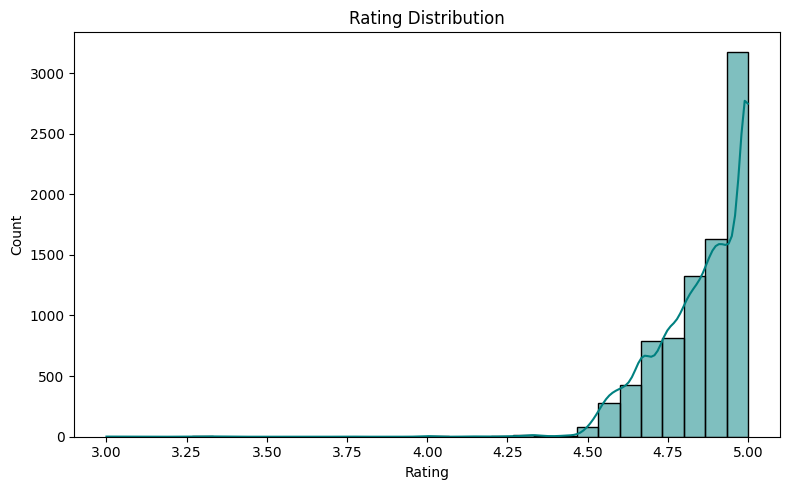

In [71]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data['rating'].dropna(),
    bins=30,
    kde=True,
    color='teal'
)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Insights
- Most Airbnb listings have ratings between 4.5 and 5.0.
- A large concentration of listings is rated very close to 5, indicating generally high customer satisfaction.
- Very few properties have ratings below 4.0.
- The distribution is left-skewed, meaning highly rated properties dominate the dataset.

### 4. Reviews Distribution

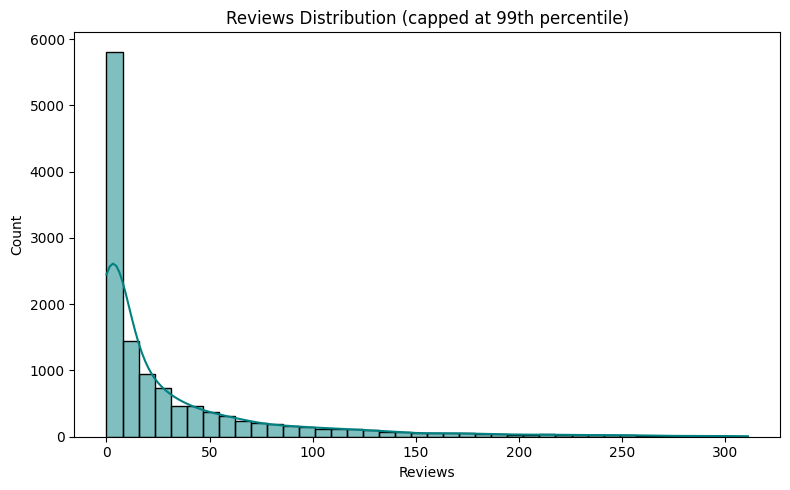

In [72]:
# Cap at 99th percentile to avoid extreme outliers distorting the chart
reviews_capped = data['reviews'][data['reviews'] <= data['reviews'].quantile(0.99)].dropna()

plt.figure(figsize=(8, 5))

sns.histplot(
    reviews_capped,
    bins=40,
    kde=True,
    color='teal'
)

plt.title('Reviews Distribution (capped at 99th percentile)')
plt.xlabel('Reviews')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Insights
- Most Airbnb listings receive a relatively low number of reviews.
- A small number of properties have extremely high review counts, acting as outliers.
- The distribution is highly right-skewed, indicating that only a few listings are very popular.
- Listings with fewer reviews are much more common across the dataset.

### 5. Rating vs Price

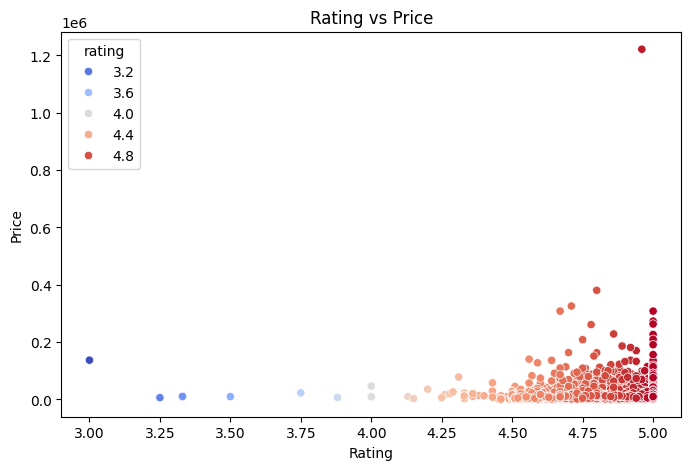

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='rating',
    y='price',
    data=data,
    hue='rating',
    palette='coolwarm'
)

plt.title('Rating vs Price')
plt.xlabel('Rating')
plt.ylabel('Price')

plt.show()

#### Insights
- Higher-rated Airbnb properties generally tend to have higher prices.
- Most listings are concentrated between ratings 4.5 and 5.0.
- A few high-priced properties appear as outliers in the dataset.
- Lower-rated properties are comparatively fewer and generally have lower prices.

### 6. Average Price by Bedrooms


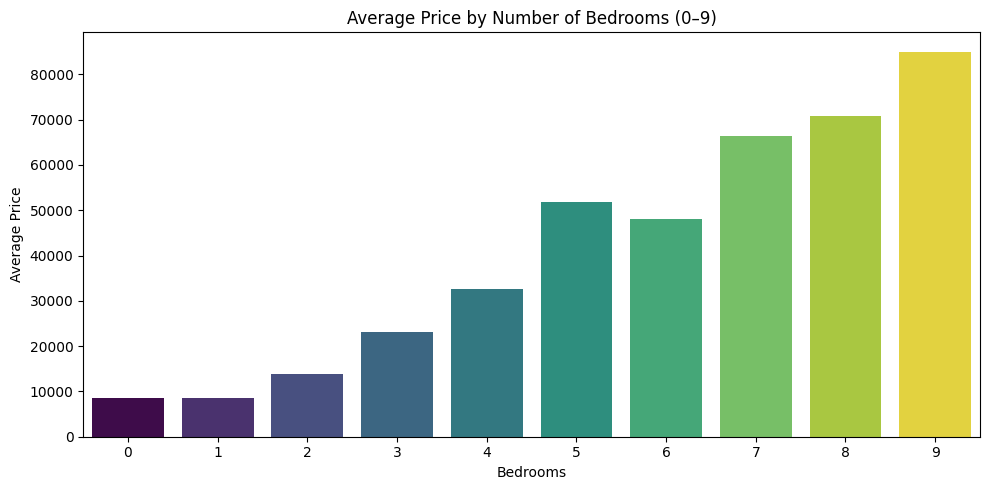

In [74]:
bedroom_price = data.groupby('bedrooms')['price'].mean().sort_index().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=bedroom_price.index.astype(int),
    y=bedroom_price.values,
    hue=bedroom_price.index.astype(int),
    palette='viridis',
    legend=False
)

plt.title('Average Price by Number of Bedrooms (0–9)')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

#### Insights
- The average Airbnb price increases as the number of bedrooms increases.
- Listings with 9 bedrooms have the highest average price in the dataset.
- Properties with 0 and 1 bedrooms have the lowest average prices.
- Larger properties tend to be more expensive due to increased space and accommodation capacity.

### 7. Reviews vs Rating

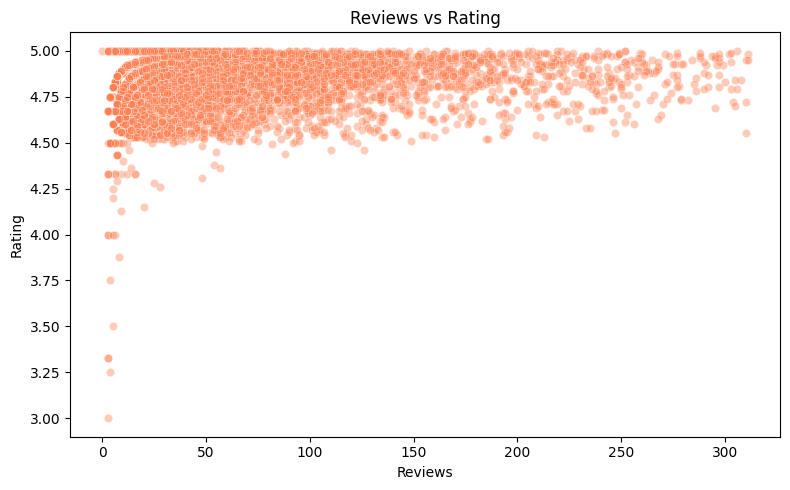

In [75]:
# Filter outliers for readability
data_r = data[data['reviews'] <= data['reviews'].quantile(0.99)].dropna(subset=['reviews', 'rating'])

plt.figure(figsize=(8, 5))

sns.scatterplot(x='reviews', y='rating', data=data_r, alpha=0.4, color='coral')

plt.title("Reviews vs Rating")
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

#### Insights
- Most listings have ratings above 4.5.
- Higher reviewed properties generally maintain high ratings.
- Few listings have low ratings.
- Customer satisfaction appears consistently high.

### 8. Correlation Heatmap

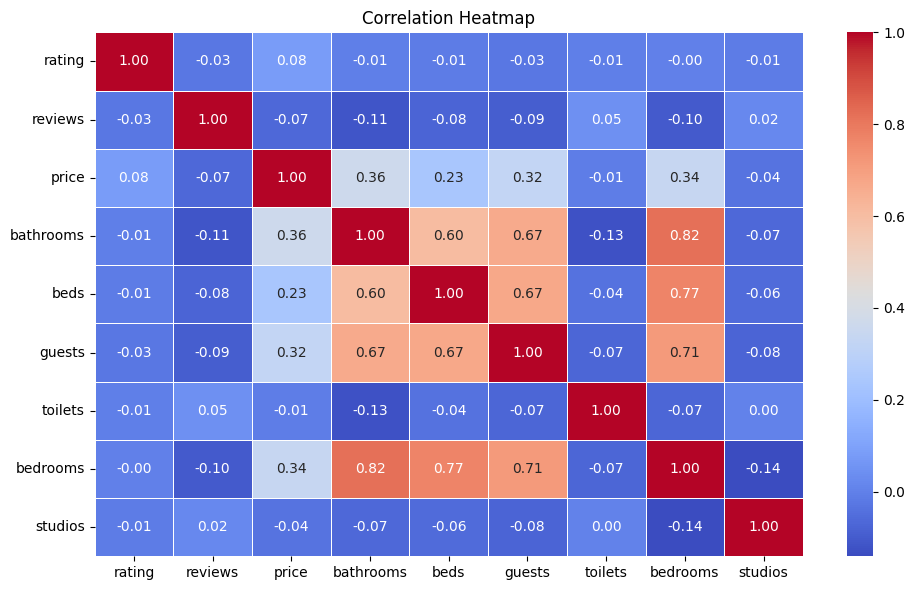

In [76]:
plt.figure(figsize=(10, 6))

corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Insights
- Bedrooms, beds, and guest capacity are strongly related.
- Larger properties usually have more bathrooms.
- Price slightly increases with property size.
- Ratings and reviews show weak correlation with other features

## Conclusion

- The Airbnb dataset analysis revealed important insights about pricing, ratings, reviews, and property features across different countries. 
- Most listings have high ratings, indicating positive customer satisfaction. Property size features such as bedrooms, beds, and guest capacity show strong relationships with pricing. 
- The analysis also highlighted that Airbnb listings are unevenly distributed across countries, with some countries having significantly more properties than others.

## Recommendations
- Hosts should maintain high service quality to achieve better ratings and customer satisfaction.
- Properties with larger accommodation capacity can be priced higher due to increased demand.
- Airbnb can focus on countries with growing listing demand for market expansion.
- New hosts can improve visibility by encouraging customer reviews and maintaining competitive pricing.
- Further analysis can be performed using location, amenities, and seasonal trends for deeper insights.

## Export Cleaned Data

In [77]:
data.to_csv("airbnb_cleaned.csv", index=False)
print("Cleaned dataset saved as airbnb_cleaned.csv")

Cleaned dataset saved as airbnb_cleaned.csv
